In [1]:
"""
Phase 5 - Rolling-origin (walk-forward) backtesting: the final, robust
comparison across every method from Phases 2-4.

THE PROBLEM THIS PHASE FIXES: every number in Phases 2, 3, and 4 was judged
against exactly ONE train/test split - train on months 1-216 (through
Dec 2023), test on the last 24 (Jan 2024-Dec 2025). Every "method X beat
method Y" conclusion so far is only true for that one specific slice of
history. A method could look good (or bad) purely because of what happened
to be in that particular 24-month window, not because it's reliably better.

THE FIX: re-run every method at MULTIPLE train/test splits ("origins"),
slid forward through history, and average performance across all of them.
Design used here - an EXPANDING window, 6 origins, 12-month test horizon
each, walking through exactly 2020-2025:

    Origin 1: train Jan2006-Dec2019 (168mo) -> test Jan2020-Dec2020
    Origin 2: train Jan2006-Dec2020 (180mo) -> test Jan2021-Dec2021
    Origin 3: train Jan2006-Dec2021 (192mo) -> test Jan2022-Dec2022
    Origin 4: train Jan2006-Dec2022 (204mo) -> test Jan2023-Dec2023
    Origin 5: train Jan2006-Dec2023 (216mo) -> test Jan2024-Dec2024
    Origin 6: train Jan2006-Dec2024 (228mo) -> test Jan2025-Dec2025

This isn't an arbitrary window count - it happens to walk straight through
the 2020 pandemic dip, the 2021-22 Great Resignation, and the two "recent"
years every earlier phase already tested on, so it's a genuine stress test:
every model has to face a real regime shift (2020) with zero advance
warning in its training data at that origin, not just the two calmer years
at the end. 240 months total is small enough that refitting every method 6
times is still cheap - the point of doing this at all.

Horizon is 12 months here (not 24, like Phases 2-4) specifically so there's
room for 6 origins instead of only 3 - a bigger, more trustworthy sample of
"how does this method typically do" instead of a single window's luck.

EVALUATION MODE - preserved per method family, not standardized, on purpose:
  - Naive / SMA(12) / WMA(12): ROLLING one-step (recomputed fresh every
    month using real data through the previous month), same as how Phase 2
    evaluated them and how anyone would actually use cheap arithmetic
    baselines in practice - no one freezes an SMA forecast for a year.
  - SES / Holt / Holt-Winters / AR / MA / ARIMA / SARIMAX / auto_arima:
    STATIC (fit once at each origin on that origin's training data, then
    forecast the full 12-month horizon in one shot), same convention as
    Phases 3-4 - these are genuinely fit models, not cheap arithmetic, and
    refitting them every month within a 12-month window isn't how they're
    normally used or reported.
Forcing every method into one identical evaluation mode would misrepresent
several of them; this keeps each in its natural, realistic mode instead.

SCOPE DECISIONS, stated explicitly:
  - SMA/WMA use window=12 only (not the full 3/6/12 sweep from Phase 2).
    Phase 2 already thoroughly answered "which window size" once; Phase 5
    is answering a different question ("which method family, robustly"),
    and re-sweeping windows here would just add rows without adding signal.
  - d (non-seasonal differencing order) and the SARIMAX seasonal order
    (1,1,1,12) are kept FIXED at the values Phase 1 and Phase 4 already
    established, at every origin. p and q (AR/MA order) ARE re-derived
    fresh at every origin from that origin's own training data (via the
    same PACF/ACF cutoff heuristic as Phase 4) - cheap to redo, and a
    genuine check on whether the suggested order is stable over time.
    (Spoiler worth knowing going in: at Origin 1, the smallest training
    window, both targets' PACF/ACF found NO lag clearing the significance
    bar at all, so p=q=0 there - AR/MA/ARIMA all degenerate to close to a
    mean-only model for that one origin specifically. From Origin 2 onward,
    orders stabilize close to Phase 4's final full-sample values. This is
    itself a real finding about order-selection reliability with limited
    data, not a bug - left in rather than special-cased away.)

LABELING NOTE: AR/MA/ARIMA/auto_arima's method labels embed the specific
order picked at that origin (e.g. "AR(3)" at one origin, "AR(0)" at
another), since that's genuinely useful detail in the per-origin CSV. But
averaging "AR(3)" and "AR(0)" as if they were different methods would
fragment the leaderboard instead of answering "how does AR, as a family,
typically perform." So every row also gets a "Family" column (the label
with any trailing "(...)" stripped) used for aggregation, while "Method"
keeps the full per-origin detail for anyone who wants it.
"""
import os
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # auto_arima's internal candidate-model search chatter (see Phase 4)

try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

sys.path.insert(0, os.path.join(BASE_DIR, "..", "src"))
from metrics import mae, rmse, mape, comparison_table  # noqa: E402

FIG_DIR = os.path.join(BASE_DIR, "..", "results", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

TARGETS = ["Headcount", "Attrition_Rate_Pct"]
HORIZON = 12
D_ORDER = {"Headcount": 1, "Attrition_Rate_Pct": 0}  # from Phase 1's ADF results, held fixed at every origin
SEASONAL_ORDER = (1, 1, 1, 12)  # same deliberately-simple choice as Phase 4, held fixed at every origin

In [2]:
df = pd.read_csv(
    os.path.join(BASE_DIR, "..", "data", "people_analytics_monthly.csv"),
    parse_dates=["Date"],
)
df = df.set_index("Date").asfreq("MS")

INITIAL_TRAIN = 168  # Jan 2006 - Dec 2019
N_ORIGINS = (len(df) - INITIAL_TRAIN) // HORIZON  # (240-168)/12 = 6

origins = []
for i in range(N_ORIGINS):
    train_end = INITIAL_TRAIN + i * HORIZON
    test_end = train_end + HORIZON
    origins.append({"train_end": train_end, "test_end": test_end})

print(f"{N_ORIGINS} rolling origins, expanding window, {HORIZON}-month test horizon each:\n")
for i, o in enumerate(origins, start=1):
    train_range = f"{df.index[0].date()} to {df.index[o['train_end']-1].date()}"
    test_range = f"{df.index[o['train_end']].date()} to {df.index[o['test_end']-1].date()}"
    print(f"  Origin {i}: train {train_range} ({o['train_end']} months)  ->  test {test_range}")

6 rolling origins, expanding window, 12-month test horizon each:

  Origin 1: train 2006-01-01 to 2019-12-01 (168 months)  ->  test 2020-01-01 to 2020-12-01
  Origin 2: train 2006-01-01 to 2020-12-01 (180 months)  ->  test 2021-01-01 to 2021-12-01
  Origin 3: train 2006-01-01 to 2021-12-01 (192 months)  ->  test 2022-01-01 to 2022-12-01
  Origin 4: train 2006-01-01 to 2022-12-01 (204 months)  ->  test 2023-01-01 to 2023-12-01
  Origin 5: train 2006-01-01 to 2023-12-01 (216 months)  ->  test 2024-01-01 to 2024-12-01
  Origin 6: train 2006-01-01 to 2024-12-01 (228 months)  ->  test 2025-01-01 to 2025-12-01


In [3]:
# (mechanical, non-fitted calculations - no need to recompute per origin, just slice per origin below)
def weighted_moving_average(series, window):
    weights = np.arange(1, window + 1)

    def _wavg(x):
        return np.dot(x, weights) / weights.sum()

    return series.shift(1).rolling(window=window).apply(_wavg, raw=True)


naive_full = {col: df[col].shift(1) for col in TARGETS}
sma12_full = {col: df[col].shift(1).rolling(window=12).mean() for col in TARGETS}
wma12_full = {col: weighted_moving_average(df[col], 12) for col in TARGETS}

In [4]:
def suggest_order(series, nlags=12, alpha=0.05):
    p_vals, p_ci = pacf(series, nlags=nlags, alpha=alpha)
    q_vals, q_ci = acf(series, nlags=nlags, alpha=alpha)

    def first_insignificant_lag(ci):
        for k in range(1, len(ci)):
            lower, upper = ci[k]
            if lower <= 0 <= upper:
                return k
        return len(ci) - 1

    p = max(first_insignificant_lag(p_ci) - 1, 0)
    q = max(first_insignificant_lag(q_ci) - 1, 0)
    return p, q

In [5]:
rows = []          # per-origin detail rows
orders_seen = []   # track (origin, target, p, q) to check order stability across origins

def add_row(origin_i, col, name, y_true, y_pred):
    family = re.sub(r"\(.*", "", name)  # "AR(3)" -> "AR", "SARIMAX(1, 1, 1, 12)" -> "SARIMAX", etc.
    rows.append({"Origin": origin_i, "Target": col, "Method": name, "Family": family,
                 "MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "MAPE_%": mape(y_true, y_pred)})


for origin_i, o in enumerate(origins, start=1):
    train_end, test_end = o["train_end"], o["test_end"]
    test_idx = df.index[train_end:test_end]

    for col in TARGETS:
        train_series = df[col].iloc[:train_end]
        y_true = df[col].iloc[train_end:test_end]

        # --- Naive / SMA(12) / WMA(12): slice the precomputed rolling series ---
        for name, series in [("Naive", naive_full[col]), ("SMA(12)", sma12_full[col]), ("WMA(12)", wma12_full[col])]:
            add_row(origin_i, col, name, y_true, series.loc[test_idx])

        # --- SES / Holt / Holt-Winters: fit fresh on this origin's training data ---
        ses = SimpleExpSmoothing(train_series, initialization_method="estimated").fit(optimized=True)
        holt = Holt(train_series, initialization_method="estimated").fit(optimized=True)
        hw = ExponentialSmoothing(
            train_series, trend="add", seasonal="add", seasonal_periods=12, initialization_method="estimated"
        ).fit(optimized=True)
        for name, model in [("SES", ses), ("Holt", holt), ("Holt-Winters", hw)]:
            y_pred = model.forecast(HORIZON)
            y_pred.index = test_idx
            add_row(origin_i, col, name, y_true, y_pred)

        # --- AR / MA / ARIMA / SARIMAX: order re-derived fresh on this origin's training data ---
        d = D_ORDER[col]
        stationary_train = train_series.diff(d).dropna() if d else train_series
        p, q = suggest_order(stationary_train)
        orders_seen.append({"Origin": origin_i, "Target": col, "p": p, "d": d, "q": q})

        ar = ARIMA(train_series, order=(p, d, 0)).fit()
        ma = ARIMA(train_series, order=(0, d, q)).fit()
        arima = ARIMA(train_series, order=(p, d, q)).fit()
        sarimax = SARIMAX(
            train_series, order=(p, d, q), seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False, maxiter=500)

        for name, model in [(f"AR({p})", ar), (f"MA({q})", ma), (f"ARIMA({p},{d},{q})", arima),
                             (f"SARIMAX{SEASONAL_ORDER}", sarimax)]:
            if name.startswith("SARIMAX"):
                y_pred = model.get_forecast(HORIZON).predicted_mean
            else:
                y_pred = model.forecast(HORIZON)
            y_pred.index = test_idx
            add_row(origin_i, col, name, y_true, y_pred)

        # --- auto_arima: automated search re-run fresh on this origin's training data ---
        auto = pm.auto_arima(
            train_series, seasonal=True, m=12,
            max_p=4, max_q=4, max_P=2, max_Q=2,
            stepwise=True, suppress_warnings=True, error_action="ignore",
        )
        y_pred = pd.Series(auto.predict(HORIZON).values, index=test_idx)
        auto_name = f"auto_arima{auto.order}x{auto.seasonal_order}"
        add_row(origin_i, col, auto_name, y_true, y_pred)

    print(f"Origin {origin_i}/{N_ORIGINS} done.")

detail = pd.DataFrame(rows)
out_detail_csv = os.path.join(BASE_DIR, "..", "results", "metrics_phase5_backtest_detail.csv")
detail.to_csv(out_detail_csv, index=False)
print(f"\nSaved per-origin detail: {out_detail_csv}  ({len(detail)} rows)")

orders_df = pd.DataFrame(orders_seen)
print("\n(p, q) picked at each origin - checking whether order selection is stable over time:")
print(orders_df.to_string(index=False))

Origin 1/6 done.
Origin 2/6 done.
Origin 3/6 done.
Origin 4/6 done.
Origin 5/6 done.
Origin 6/6 done.

Saved per-origin detail: /sessions/wizardly-confident-brahmagupta/mnt/gitpush/forecasting_arima/notebooks/../results/metrics_phase5_backtest_detail.csv  (132 rows)

(p, q) picked at each origin - checking whether order selection is stable over time:
 Origin             Target  p  d  q
      1          Headcount  0  1  0
      1 Attrition_Rate_Pct  0  0  0
      2          Headcount  3  1  4
      2 Attrition_Rate_Pct  3  0  3
      3          Headcount  3  1  5
      3 Attrition_Rate_Pct  3  0  5
      4          Headcount  3  1  5
      4 Attrition_Rate_Pct  3  0  6
      5          Headcount  3  1  5
      5 Attrition_Rate_Pct  3  0  6
      6          Headcount  3  1  5
      6 Attrition_Rate_Pct  3  0  7


In [6]:
# Grouped by Family (not the exact per-origin Method label) so e.g. "AR(3)" at one origin and "AR(0)"
# at another correctly average together as one "AR" row, instead of fragmenting - see LABELING NOTE above.
summary = (
    detail.groupby(["Target", "Family"])
    .agg(Mean_MAE=("MAE", "mean"), Mean_RMSE=("RMSE", "mean"), Std_RMSE=("RMSE", "std"), Mean_MAPE_pct=("MAPE_%", "mean"))
    .reset_index()
)
summary = summary.sort_values(["Target", "Mean_RMSE"]).reset_index(drop=True)

print("\nPhase 5 final leaderboard - averaged across all 6 rolling origins, best (lowest mean RMSE) first:")
print(summary.to_string(index=False))

out_summary_csv = os.path.join(BASE_DIR, "..", "results", "metrics_phase5_backtest_summary.csv")
summary.to_csv(out_summary_csv, index=False)
print(f"\nSaved leaderboard: {out_summary_csv}")


Phase 5 final leaderboard - averaged across all 6 rolling origins, best (lowest mean RMSE) first:
            Target       Family  Mean_MAE  Mean_RMSE  Std_RMSE  Mean_MAPE_pct
Attrition_Rate_Pct          SMA  0.692188   0.838849  0.174689      38.260357
Attrition_Rate_Pct          WMA  0.701802   0.848422  0.148544      39.071469
Attrition_Rate_Pct          SES  0.728435   0.867224  0.244915      38.511063
Attrition_Rate_Pct         Holt  0.734741   0.872915  0.237866      39.558494
Attrition_Rate_Pct   auto_arima  0.773544   0.923398  0.386409      39.222236
Attrition_Rate_Pct Holt-Winters  0.814101   0.968849  0.367144      43.089923
Attrition_Rate_Pct      SARIMAX  0.797267   0.976026  0.432897      37.026003
Attrition_Rate_Pct        ARIMA  0.828839   1.006217  0.439635      35.742244
Attrition_Rate_Pct           AR  0.854681   1.046765  0.435604      35.067324
Attrition_Rate_Pct        Naive  0.874861   1.051522  0.170893      48.300894
Attrition_Rate_Pct           MA  0.890855  

In [7]:
# every month within the 12-month test window), while every other method is evaluated STATIC (fit once,
# forecast the whole 12 months blind). That's not a subtle difference - it means Naive/SMA/WMA aren't
# really being asked the same question as the fitted models, and comparing them head-to-head in one
# leaderboard isn't fully apples-to-apples (exactly the rolling-vs-static gap Phase 2 already showed:
# rolling SMA(12) RMSE 13.39 vs. the SAME method held static, RMSE 34.43 - rolling has a real, large,
# built-in advantage that has nothing to do with which method is "smarter"). So alongside the full
# leaderboard above, here's a second one restricted to only the STATIC-mode methods - the fair,
# like-for-like comparison to Phase 4's single-split numbers, which were also all static.
STATIC_FAMILIES = ["SES", "Holt", "Holt-Winters", "AR", "MA", "ARIMA", "SARIMAX", "auto_arima"]
summary_static = summary[summary["Family"].isin(STATIC_FAMILIES)].reset_index(drop=True)

print("Static-only leaderboard (fair comparison group - excludes rolling Naive/SMA/WMA):")
print(summary_static.to_string(index=False))

single_split_champion = {
    "Headcount": ("SARIMAX", 3.018),
    "Attrition_Rate_Pct": ("auto_arima", 0.643),
}
print("\nSingle-split (Phase 4) champion vs. backtest-averaged (Phase 5) champion, static-only:")
for col in TARGETS:
    backtest_best = summary_static[summary_static["Target"] == col].iloc[0]
    ss_family, ss_rmse = single_split_champion[col]
    print(f"\n{col}:")
    print(f"  Phase 4 single-split champion: {ss_family}  (RMSE={ss_rmse:.3f} on ONE 24-month test window)")
    print(f"  Phase 5 backtest champion:     {backtest_best['Family']}  "
          f"(mean RMSE={backtest_best['Mean_RMSE']:.3f} +/- {backtest_best['Std_RMSE']:.3f} across 6 origins)")
    agree = "AGREE" if ss_family == backtest_best["Family"] else "DISAGREE"
    print(f"  -> {agree} on which method family wins")

Static-only leaderboard (fair comparison group - excludes rolling Naive/SMA/WMA):
            Target       Family  Mean_MAE  Mean_RMSE  Std_RMSE  Mean_MAPE_pct
Attrition_Rate_Pct          SES  0.728435   0.867224  0.244915      38.511063
Attrition_Rate_Pct         Holt  0.734741   0.872915  0.237866      39.558494
Attrition_Rate_Pct   auto_arima  0.773544   0.923398  0.386409      39.222236
Attrition_Rate_Pct Holt-Winters  0.814101   0.968849  0.367144      43.089923
Attrition_Rate_Pct      SARIMAX  0.797267   0.976026  0.432897      37.026003
Attrition_Rate_Pct        ARIMA  0.828839   1.006217  0.439635      35.742244
Attrition_Rate_Pct           AR  0.854681   1.046765  0.435604      35.067324
Attrition_Rate_Pct           MA  0.890855   1.089008  0.439234      35.634948
         Headcount      SARIMAX  5.215726   6.430000  6.024166       1.289864
         Headcount   auto_arima  5.149178   6.934710  6.968693       1.268597
         Headcount           AR  5.483818   7.056131  6.3889


Saved 09_backtest_rmse_by_origin.png


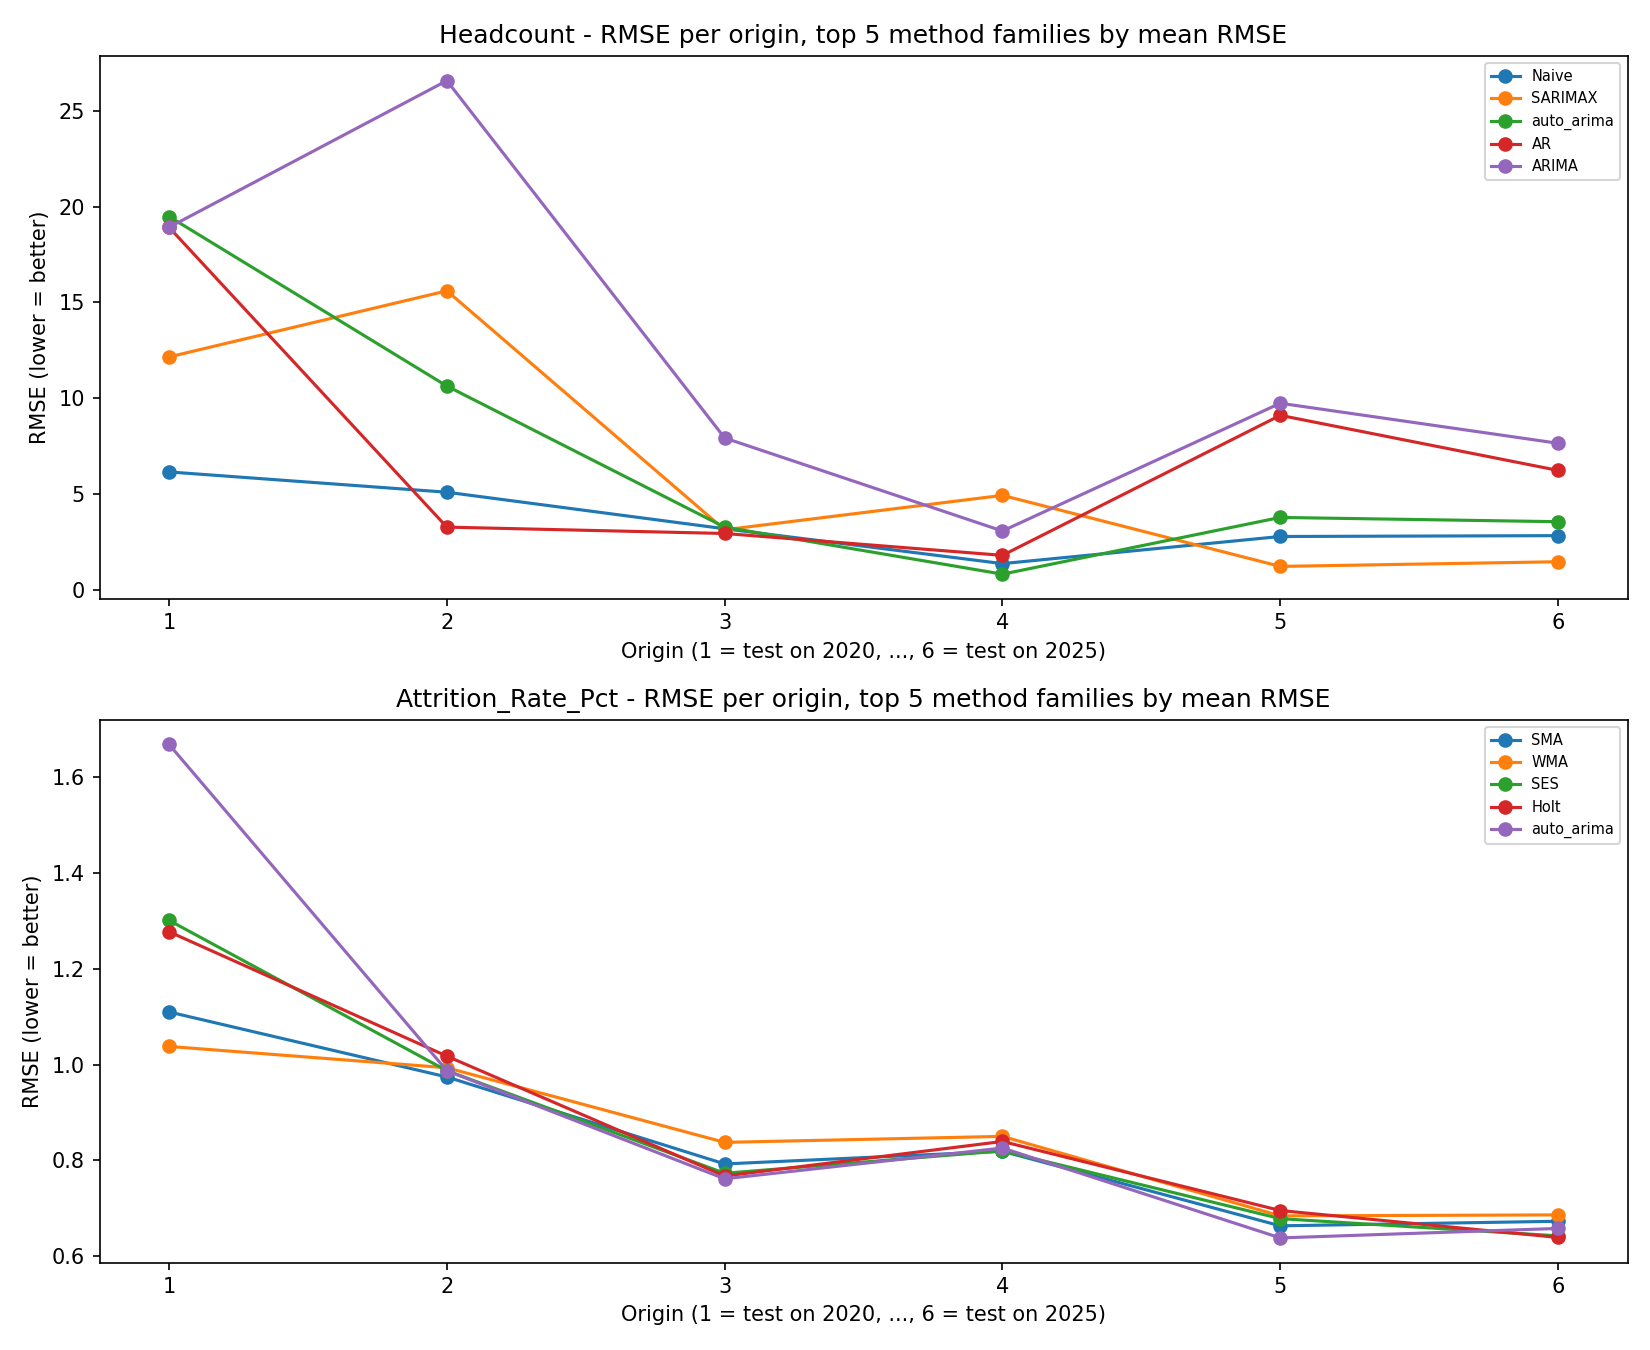

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9))
for ax, col in zip(axes, TARGETS):
    top_families = summary[summary["Target"] == col]["Family"].head(5).tolist()
    for fam in top_families:
        sub = detail[(detail["Target"] == col) & (detail["Family"] == fam)].sort_values("Origin")
        ax.plot(sub["Origin"], sub["RMSE"], marker="o", label=fam)
    ax.set_xticks(range(1, N_ORIGINS + 1))
    ax.set_xlabel("Origin (1 = test on 2020, ..., 6 = test on 2025)")
    ax.set_ylabel("RMSE (lower = better)")
    ax.set_title(f"{col} - RMSE per origin, top 5 method families by mean RMSE")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_backtest_rmse_by_origin.png"), dpi=150)
plt.close()
print("\nSaved 09_backtest_rmse_by_origin.png")

Saved 10_backtest_leaderboard.png

Done. Report back: which method actually wins on average for each target? Does it agree with Phase 4's single-split champion, or does testing on more windows change the answer? And which methods are most CONSISTENT (low std dev) vs. most erratic (high std dev) across the 6 origins?


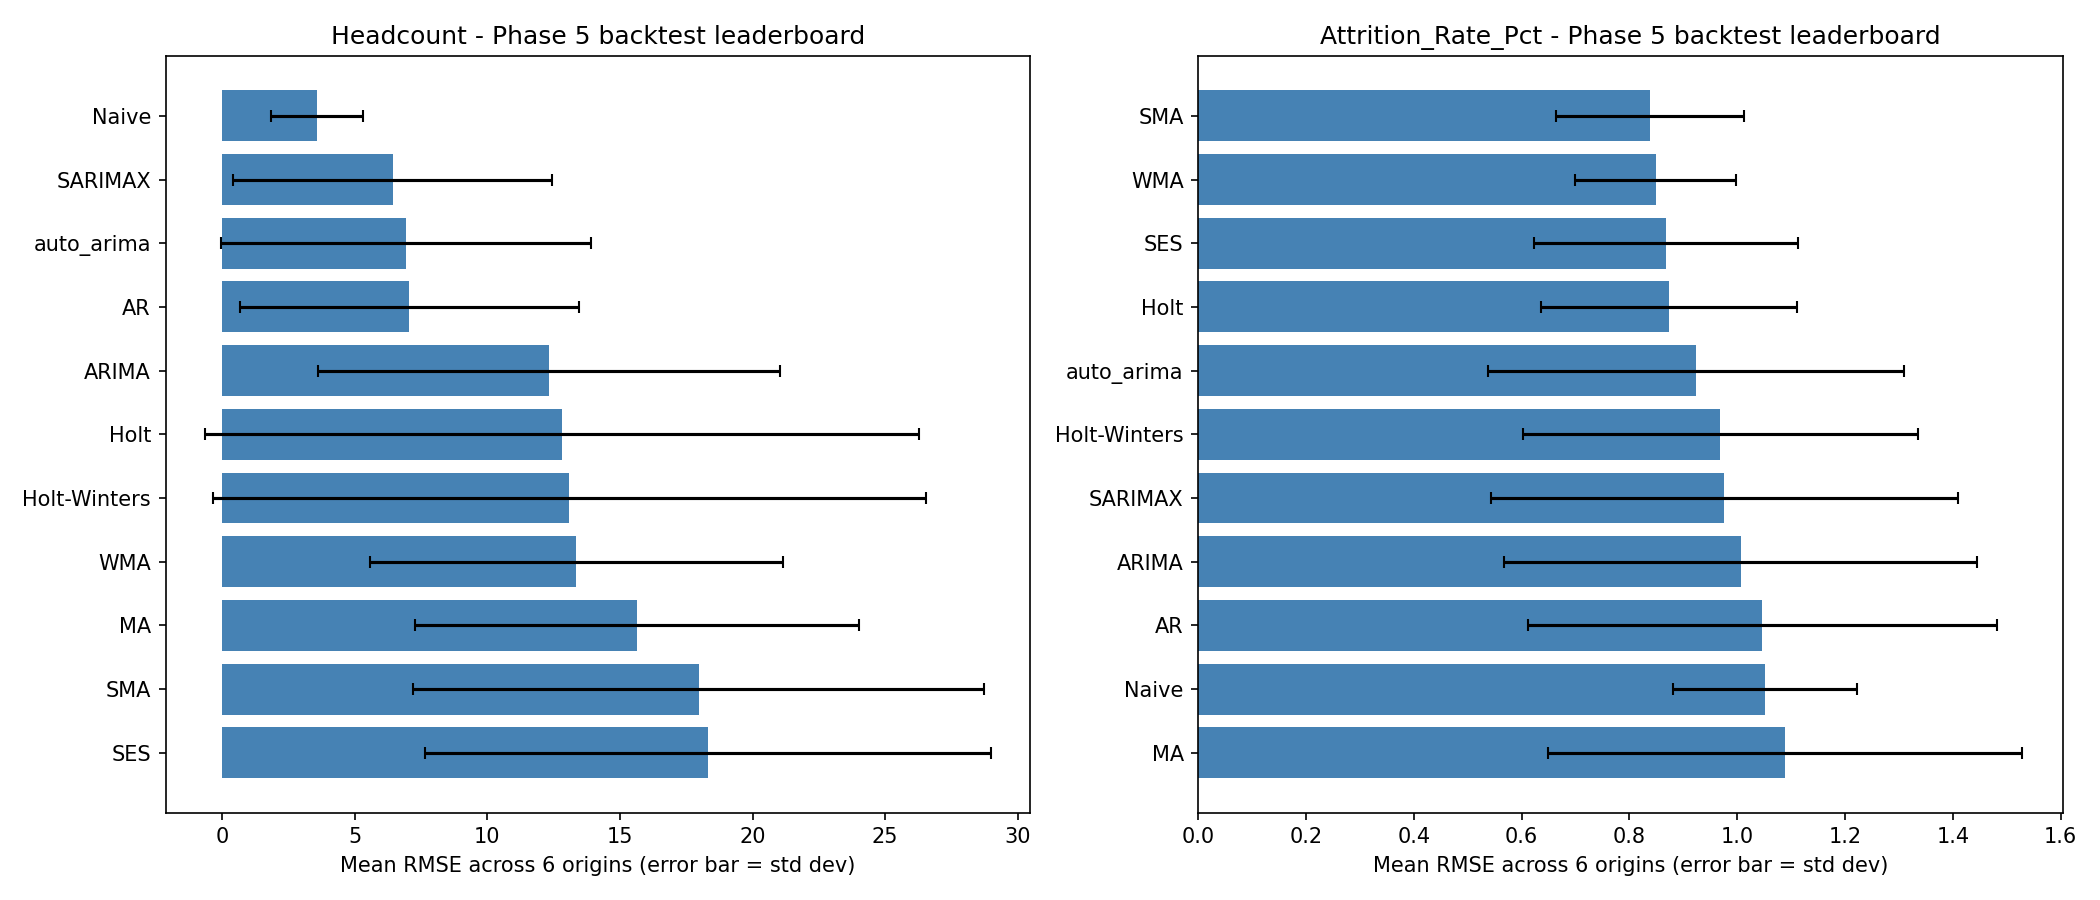

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col in zip(axes, TARGETS):
    sub = summary[summary["Target"] == col]
    ax.barh(sub["Family"], sub["Mean_RMSE"], xerr=sub["Std_RMSE"].fillna(0), color="steelblue", capsize=3)
    ax.invert_yaxis()  # best (lowest RMSE) at the top
    ax.set_xlabel("Mean RMSE across 6 origins (error bar = std dev)")
    ax.set_title(f"{col} - Phase 5 backtest leaderboard")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_backtest_leaderboard.png"), dpi=150)
plt.close()
print("Saved 10_backtest_leaderboard.png")

print("\nDone. Report back: which method actually wins on average for each target? Does it agree with "
      "Phase 4's single-split champion, or does testing on more windows change the answer? And which "
      "methods are most CONSISTENT (low std dev) vs. most erratic (high std dev) across the 6 origins?")